# Mini Project: Loan Default & Credit Risk Analysis

**Domain:** Retail Banking & Credit Risk Management  
**Role:** Data Analyst  
**Objective:** Analyze customer demographics, income, credit score, loan amount, repayment history, debt-to-income ratio, and loan default patterns to generate actionable credit-risk insights.  
**Tools & Technologies:** Python (NumPy, Pandas, Matplotlib, Seaborn), Power BI Desktop, DAX, Power Query.


---
## PART 1 — DATA LOADING

In this section, we import the core data science libraries and load the retail loan dataset. We examine the first and last records, inspect the dataset dimensions, and list all column attributes.


In [1]:
# Step 1: Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Step 2: Load the loan dataset using Pandas
raw_data_path = os.path.join("..", "Dataset", "Loan_Credit_Risk_Raw.csv")
if not os.path.exists(raw_data_path):
    raw_data_path = os.path.join("Dataset", "Loan_Credit_Risk_Raw.csv")

df_raw = pd.read_csv(raw_data_path)
print(f"Dataset successfully loaded from: {raw_data_path}")


Dataset successfully loaded from: Dataset\Loan_Credit_Risk_Raw.csv


In [3]:
# Step 3: Display the first five records
df_raw.head()


,Customer_ID,Gender,Age,Education,Employment_Status,Marital_Status,Dependents,Annual_Income,Credit_Score,Existing_Loans,...,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Employment_Years,Previous_Defaults,Credit_History,Property_Ownership,Region,Loan_Status,Default_Status
0,CUST-1001,Male,60,Bachelor,Self-Employed,Single,1,99600.0,811.0,0,...,11.15,700.16,0.084,27.0,0,Excellent,Mortgage,South,Current,No
1,CUST-1002,Female,27,Bachelor,Employed,Married,0,69400.0,550.0,1,...,18.75,820.54,0.189,5.0,0,Poor,Own,East,Current,No
2,CUST-1003,Female,52,PhD,Employed,Divorced,0,220000.0,540.0,2,...,14.68,1607.56,0.106,3.0,0,Poor,Rent,South,Current,No
3,CUST-1004,Female,39,Bachelor,Employed,Divorced,3,43700.0,589.0,3,...,17.82,2671.27,0.750,15.0,0,Fair,Mortgage,East,Defaulted,Yes
4,CUST-1005,Male,26,Bachelor,Employed,Divorced,3,33600.0,765.0,2,...,14.64,228.93,0.191,3.0,0,Excellent,Mortgage,West,Current,No


In [4]:
# Step 4: Display the last five records
df_raw.tail()


,Customer_ID,Gender,Age,Education,Employment_Status,Marital_Status,Dependents,Annual_Income,Credit_Score,Existing_Loans,...,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Employment_Years,Previous_Defaults,Credit_History,Property_Ownership,Region,Loan_Status,Default_Status
5020,CUST-2493,Male,32,Bachelor,Employed,Married,2,28300.0,545.0,0,...,13.82,2280.64,0.750,5.0,1,Poor,Mortgage,South,Defaulted,Yes
5021,CUST-4721,Male,34,Bachelor,Self-Employed,Married,1,114100.0,624.0,2,...,13.29,3337.47,0.396,3.0,0,Fair,Mortgage,South,Current,No
5022,CUST-1619,Female,59,High School,Employed,Single,0,60900.0,736.0,2,...,15.63,160.46,0.122,21.0,0,Good,Rent,South,Fully Paid,No
5023,CUST-4490,Male,63,Bachelor,Unemployed,Married,0,31100.0,612.0,3,...,12.91,6740.27,0.750,0.0,0,Fair,Mortgage,East,Current,No
5024,CUST-3146,Female,55,Master,Employed,Married,0,51900.0,658.0,2,...,13.56,712.30,0.260,5.0,0,Fair,Rent,West,Fully Paid,No


In [5]:
# Step 5: Check the dataset shape
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")


Dataset Shape: 5025 rows, 24 columns


In [6]:
# Step 6: Display all column names
print("Column Names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. Customer_ID
 2. Gender
 3. Age
 4. Education
 5. Employment_Status
 6. Marital_Status
 7. Dependents
 8. Annual_Income
 9. Credit_Score
10. Existing_Loans
11. Loan_ID
12. Loan_Type
13. Loan_Amount
14. Loan_Term_Months
15. Interest_Rate
16. Monthly_Installment
17. Debt_to_Income_Ratio
18. Employment_Years
19. Previous_Defaults
20. Credit_History
21. Property_Ownership
22. Region
23. Loan_Status
24. Default_Status


---
## PART 2 — DATA EXPLORATION & CLEANING

We perform rigorous exploratory data inspection: identifying data types, evaluating summary statistics, detecting missing values and duplicates, and treating data entry anomalies and outliers.


In [7]:
# Step 7: Check data types
df_raw.dtypes


Customer_ID              object
Gender                   object
Age                       int64
Education                object
Employment_Status        object
Marital_Status           object
Dependents                int64
Annual_Income           float64
Credit_Score            float64
Existing_Loans            int64
Loan_ID                  object
Loan_Type                object
Loan_Amount             float64
Loan_Term_Months          int64
Interest_Rate           float64
Monthly_Installment     float64
Debt_to_Income_Ratio    float64
Employment_Years        float64
Previous_Defaults         int64
Credit_History           object
Property_Ownership       object
Region                   object
Loan_Status              object
Default_Status           object
dtype: object

In [8]:
# Step 8: Display statistical information
df_raw.describe().round(2)


,Age,Dependents,Annual_Income,Credit_Score,Existing_Loans,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Employment_Years,Previous_Defaults
count,5025.00,5025.00,4982.00,4997.00,5025.00,5025.00,5025.00,5025.00,5025.00,5003.00,4989.00,5025.00
mean,43.64,1.03,69525.29,667.18,1.36,41701.53,36.27,14.17,1695.26,0.36,9.00,0.18
std,13.42,1.11,38260.08,85.46,1.22,34847.69,14.42,2.65,1673.43,0.24,8.69,0.51
min,21.00,0.00,-45000.00,300.00,0.00,3000.00,12.00,6.56,76.77,0.08,0.00,0.00
25%,32.00,0.00,42700.00,607.00,0.00,17800.00,24.00,12.35,626.87,0.15,2.00,0.00
50%,44.00,1.00,62000.00,668.00,1.00,29900.00,36.00,14.19,1101.46,0.29,6.00,0.00
75%,55.00,2.00,87200.00,727.00,2.00,58400.00,48.00,16.06,2263.10,0.56,14.00,0.00
max,67.00,4.00,220000.00,850.00,5.00,999999.00,60.00,23.85,11572.28,0.75,39.00,3.00


In [9]:
# Step 9: Check missing values
missing_val = df_raw.isnull().sum()
missing_val[missing_val > 0]


Annual_Income           43
Credit_Score            28
Debt_to_Income_Ratio    22
Employment_Years        36
dtype: int64

In [10]:
# Step 10: Check duplicate records
duplicate_count = df_raw.duplicated(subset=['Customer_ID']).sum()
print(f"Number of duplicate customer records found: {duplicate_count}")


Number of duplicate customer records found: 25


In [11]:
# Step 11: Remove duplicates if any
df_cleaned = df_raw.drop_duplicates(subset=['Customer_ID'], keep='first').copy().reset_index(drop=True)
print(f"Clean customer records remaining: {len(df_cleaned)}")


Clean customer records remaining: 5000


In [12]:
# Step 12: Check unique values in categorical columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col} ({df_cleaned[col].nunique()} unique): {list(df_cleaned[col].unique()[:5])}")


Customer_ID (5000 unique): ['CUST-1001', 'CUST-1002', 'CUST-1003', 'CUST-1004', 'CUST-1005']
Gender (2 unique): ['Male', 'Female']
Education (4 unique): ['Bachelor', 'PhD', 'High School', 'Master']
Employment_Status (3 unique): ['Self-Employed', 'Employed', 'Unemployed']
Marital_Status (3 unique): ['Single', 'Married', 'Divorced']
Loan_ID (5000 unique): ['LN-2023-10001', 'LN-2023-10002', 'LN-2023-10003', 'LN-2023-10004', 'LN-2023-10005']
Loan_Type (5 unique): ['Auto', 'Personal', 'Home', 'Business', 'Education']
Credit_History (4 unique): ['Excellent', 'Poor', 'Fair', 'Good']
Property_Ownership (3 unique): ['Mortgage', 'Own', 'Rent']
Region (5 unique): ['South', 'East', 'West', 'Central', 'North']
Loan_Status (3 unique): ['Current', 'Defaulted', 'Fully Paid']
Default_Status (2 unique): ['No', 'Yes']


In [13]:
# Step 13: Handle missing values appropriately
# Fix negative income entry error
df_cleaned.loc[df_cleaned['Annual_Income'] < 0, 'Annual_Income'] = np.nan

# Impute Annual_Income using Education & Employment Status median
group_inc_median = df_cleaned.groupby(['Education', 'Employment_Status'])['Annual_Income'].transform('median')
df_cleaned['Annual_Income'] = df_cleaned['Annual_Income'].fillna(group_inc_median).fillna(df_cleaned['Annual_Income'].median())

# Impute other numerical features using medians
df_cleaned['Employment_Years'] = df_cleaned['Employment_Years'].fillna(df_cleaned['Employment_Years'].median())
df_cleaned['Credit_Score'] = df_cleaned['Credit_Score'].fillna(df_cleaned['Credit_Score'].median())
df_cleaned['Debt_to_Income_Ratio'] = df_cleaned['Debt_to_Income_Ratio'].fillna(df_cleaned['Debt_to_Income_Ratio'].median())

print("Missing values after imputation:")
print(df_cleaned[['Annual_Income', 'Employment_Years', 'Credit_Score', 'Debt_to_Income_Ratio']].isnull().sum())


Missing values after imputation:
Annual_Income           0
Employment_Years        0
Credit_Score            0
Debt_to_Income_Ratio    0
dtype: int64


In [14]:
# Step 14: Check numerical outliers
# Cap/correct extreme data entry typo in Loan_Amount (> $200,000)
extreme_loan = df_cleaned['Loan_Amount'] > 200000
if extreme_loan.any():
    median_loan = df_cleaned.loc[~extreme_loan, 'Loan_Amount'].median()
    df_cleaned.loc[extreme_loan, 'Loan_Amount'] = median_loan

# Recalculate monthly installment for corrected loan amount
for idx in df_cleaned[extreme_loan].index:
    P = df_cleaned.loc[idx, 'Loan_Amount']
    r_ann = df_cleaned.loc[idx, 'Interest_Rate']
    n = df_cleaned.loc[idx, 'Loan_Term_Months']
    r_mo = (r_ann / 100.0) / 12.0
    df_cleaned.loc[idx, 'Monthly_Installment'] = round(P * (r_mo * (1 + r_mo)**n) / ((1 + r_mo)**n - 1), 2)

# Create Credit Score Group
bins_cs = [300, 579, 669, 739, 799, 850]
labels_cs = ['Poor (<580)', 'Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Excellent (800+)']
df_cleaned['Credit_Score_Group'] = pd.cut(df_cleaned['Credit_Score'], bins=bins_cs, labels=labels_cs, include_lowest=True)

# Create Income Group
bins_inc = [0, 40000, 65000, 95000, np.inf]
labels_inc = ['Low (<$40k)', 'Lower-Middle ($40k-$65k)', 'Upper-Middle ($65k-$95k)', 'High (>$95k)']
df_cleaned['Income_Group'] = pd.cut(df_cleaned['Annual_Income'], bins=bins_inc, labels=labels_inc)

# Numeric default indicator
df_cleaned['Default_Numeric'] = (df_cleaned['Default_Status'] == 'Yes').astype(int)

print("Data grouping & outlier handling completed.")


Data grouping & outlier handling completed.


In [15]:
# Step 15: Verify the cleaned dataset
print(f"Remaining Missing Values: {df_cleaned.isnull().sum().sum()}")
print(f"Remaining Duplicate Records: {df_cleaned.duplicated().sum()}")
print(f"Cleaned Dataset Final Shape: {df_cleaned.shape}")

cleaned_out_path = os.path.join("..", "Dataset", "Loan_Credit_Risk_Cleaned.csv")
if not os.path.exists(os.path.dirname(cleaned_out_path)):
    cleaned_out_path = os.path.join("Dataset", "Loan_Credit_Risk_Cleaned.csv")
df_cleaned.to_csv(cleaned_out_path, index=False)
print(f"Cleaned dataset saved to: {cleaned_out_path}")


Remaining Missing Values: 0
Remaining Duplicate Records: 0
Cleaned Dataset Final Shape: (5000, 27)


Cleaned dataset saved to: Dataset\Loan_Credit_Risk_Cleaned.csv


---
## PART 3 — DATA ANALYSIS

Addressing all quantitative analytical questions (Items 16 to 44) regarding retail portfolio credit performance, risk segments, and borrower behavior.


In [16]:
# Items 16 - 25: Portfolio Summary Metrics
total_customers = df_cleaned['Customer_ID'].nunique()
total_loans = df_cleaned['Loan_ID'].nunique()
defaulted_loans = (df_cleaned['Default_Status'] == 'Yes').sum()
non_defaulted_loans = (df_cleaned['Default_Status'] == 'No').sum()
overall_default_rate = (defaulted_loans / total_loans) * 100
avg_annual_income = df_cleaned['Annual_Income'].mean()
avg_credit_score = df_cleaned['Credit_Score'].mean()
avg_loan_amount = df_cleaned['Loan_Amount'].mean()
avg_interest_rate = df_cleaned['Interest_Rate'].mean()
avg_dti = df_cleaned['Debt_to_Income_Ratio'].mean()

print(f"16. Total Customers: {total_customers:,}")
print(f"17. Total Loans: {total_loans:,}")
print(f"18. Defaulted Loans: {defaulted_loans:,}")
print(f"19. Non-Defaulted Loans: {non_defaulted_loans:,}")
print(f"20. Overall Default Rate: {overall_default_rate:.2f}%")
print(f"21. Average Annual Income: ${avg_annual_income:,.2f}")
print(f"22. Average Credit Score: {avg_credit_score:.2f}")
print(f"23. Average Loan Amount: ${avg_loan_amount:,.2f}")
print(f"24. Average Interest Rate: {avg_interest_rate:.2f}%")
print(f"25. Average Debt-to-Income (DTI) Ratio: {avg_dti:.4f} ({avg_dti*100:.2f}%)")


16. Total Customers: 5,000
17. Total Loans: 5,000
18. Defaulted Loans: 955
19. Non-Defaulted Loans: 4,045
20. Overall Default Rate: 19.10%
21. Average Annual Income: $69,486.35
22. Average Credit Score: 667.10
23. Average Loan Amount: $41,449.30
24. Average Interest Rate: 14.18%
25. Average Debt-to-Income (DTI) Ratio: 0.3571 (35.71%)


In [17]:
# Item 26: Number of loans by loan type
print("26. Loans by Loan Type:")
print(df_cleaned['Loan_Type'].value_counts())


26. Loans by Loan Type:
Loan_Type
Personal     1474
Home         1203
Auto         1123
Education     715
Business      485
Name: count, dtype: int64


In [18]:
# Item 27: Number of loans by region
print("27. Loans by Region:")
print(df_cleaned['Region'].value_counts())


27. Loans by Region:
Region
North      1247
South      1048
East       1026
West        939
Central     740
Name: count, dtype: int64


In [19]:
# Items 28 - 33: Default Rates across Dimensions
print("28. Default Rate by Loan Type:")
print(df_cleaned.groupby('Loan_Type')['Default_Numeric'].agg(['count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={'<lambda_0>': 'Default_Rate_%'}))

print("\n29. Default Rate by Employment Status:")
print(df_cleaned.groupby('Employment_Status')['Default_Numeric'].agg(['count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={'<lambda_0>': 'Default_Rate_%'}))

print("\n30. Default Rate by Education:")
print(df_cleaned.groupby('Education')['Default_Numeric'].agg(['count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={'<lambda_0>': 'Default_Rate_%'}))

print("\n31. Default Rate by Property Ownership:")
print(df_cleaned.groupby('Property_Ownership')['Default_Numeric'].agg(['count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={'<lambda_0>': 'Default_Rate_%'}))

print("\n32. Default Rate by Credit-Score Group:")
print(df_cleaned.groupby('Credit_Score_Group', observed=False)['Default_Numeric'].agg(['count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={'<lambda_0>': 'Default_Rate_%'}))

print("\n33. Default Rate by Income Group:")
print(df_cleaned.groupby('Income_Group', observed=False)['Default_Numeric'].agg(['count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={'<lambda_0>': 'Default_Rate_%'}))


28. Default Rate by Loan Type:
           count Default_Rate_%
Loan_Type                      
Auto        1123         14.43%
Business     485         23.92%
Education    715         13.15%
Home        1203         34.91%
Personal    1474         11.06%

29. Default Rate by Employment Status:
                   count Default_Rate_%
Employment_Status                      
Employed            3465         17.23%
Self-Employed       1136         15.67%
Unemployed           399         45.11%

30. Default Rate by Education:
             count Default_Rate_%
Education                        
Bachelor      2442         19.98%
High School   1241         22.80%
Master        1015         14.48%
PhD            302         12.25%

31. Default Rate by Property Ownership:
                    count Default_Rate_%
Property_Ownership                      
Mortgage             1858         18.14%
Own                   893         20.72%
Rent                 2249         19.25%

32. Default Rate by Cr

In [20]:
# Items 34 - 37: Customer Risk Filtering & Top Customers
below_avg_cs = df_cleaned[df_cleaned['Credit_Score'] < avg_credit_score]
above_avg_loan = df_cleaned[df_cleaned['Loan_Amount'] > avg_loan_amount]
high_dti = df_cleaned[df_cleaned['Debt_to_Income_Ratio'] > 0.40]

print(f"34. Customers with below-average credit score: {len(below_avg_cs):,} | Default Rate: {below_avg_cs['Default_Numeric'].mean()*100:.2f}%")
print(f"35. Customers with above-average loan amount: {len(above_avg_loan):,} | Default Rate: {above_avg_loan['Default_Numeric'].mean()*100:.2f}%")
print(f"36. Customers with high DTI (> 0.40): {len(high_dti):,} | Default Rate: {high_dti['Default_Numeric'].mean()*100:.2f}%")

print("\n37. Top 10 Customers Based on Loan Amount:")
df_cleaned.nlargest(10, 'Loan_Amount')[['Customer_ID', 'Loan_ID', 'Loan_Type', 'Loan_Amount', 'Annual_Income', 'Credit_Score', 'Default_Status']]


34. Customers with below-average credit score: 2,480 | Default Rate: 27.22%
35. Customers with above-average loan amount: 1,748 | Default Rate: 31.18%
36. Customers with high DTI (> 0.40): 1,837 | Default Rate: 34.30%

37. Top 10 Customers Based on Loan Amount:


,Customer_ID,Loan_ID,Loan_Type,Loan_Amount,Annual_Income,Credit_Score,Default_Status
2330,CUST-3331,LN-2023-12331,Home,130000.0,31200.0,667.0,No
304,CUST-1305,LN-2023-10305,Home,129900.0,93200.0,631.0,No
1555,CUST-2556,LN-2023-11556,Home,129700.0,34700.0,850.0,No
1725,CUST-2726,LN-2023-11726,Home,129700.0,66200.0,706.0,No
4514,CUST-5515,LN-2023-14515,Home,129700.0,191900.0,624.0,Yes
17,CUST-1018,LN-2023-10018,Home,129500.0,99800.0,745.0,No
2131,CUST-3132,LN-2023-12132,Home,129500.0,23400.0,675.0,Yes
119,CUST-1120,LN-2023-10120,Home,129300.0,33100.0,668.0,Yes
1942,CUST-2943,LN-2023-11943,Home,129300.0,63400.0,678.0,No
236,CUST-1237,LN-2023-10237,Home,129200.0,94100.0,748.0,No


In [21]:
# Items 38 - 39: Highest Default Loan Type and Region
highest_lt = df_cleaned.groupby('Loan_Type')['Default_Numeric'].mean().idxmax()
highest_lt_val = df_cleaned.groupby('Loan_Type')['Default_Numeric'].mean().max() * 100
highest_reg = df_cleaned.groupby('Region')['Default_Numeric'].mean().idxmax()
highest_reg_val = df_cleaned.groupby('Region')['Default_Numeric'].mean().max() * 100

print(f"38. Loan Type with highest default rate: {highest_lt} ({highest_lt_val:.2f}%)")
print(f"39. Region with highest default rate: {highest_reg} ({highest_reg_val:.2f}%)")


38. Loan Type with highest default rate: Home (34.91%)


39. Region with highest default rate: South (20.13%)


In [22]:
# Items 40 - 43: Comparative Driver Analyses
print("40. Credit Score vs Default:")
display(df_cleaned.groupby('Default_Status')['Credit_Score'].agg(['count', 'mean', 'median', 'std']).round(2))

print("\n41. Annual Income vs Default:")
display(df_cleaned.groupby('Default_Status')['Annual_Income'].agg(['count', 'mean', 'median', 'std']).round(2))

print("\n42. Loan Amount vs Default:")
display(df_cleaned.groupby('Default_Status')['Loan_Amount'].agg(['count', 'mean', 'median', 'std']).round(2))

print("\n43. Previous Defaults vs Current Default:")
display((pd.crosstab(df_cleaned['Previous_Defaults'], df_cleaned['Default_Status'], normalize='index') * 100).round(2))


40. Credit Score vs Default:


,count,mean,median,std
Default_Status,,,,
No,4045,678.12,678.0,82.35
Yes,955,620.42,621.0,81.27



41. Annual Income vs Default:


,count,mean,median,std
Default_Status,,,,
No,4045,73082.48,65200.0,38382.52
Yes,955,54254.55,47700.0,32362.25



42. Loan Amount vs Default:


,count,mean,median,std
Default_Status,,,,
No,4045,37242.42,27700.0,29237.57
Yes,955,59267.96,50900.0,37128.11



43. Previous Defaults vs Current Default:


Default_Status,No,Yes
Previous_Defaults,,
0,84.43,15.57
1,60.43,39.57
2,54.01,45.99
3,36.73,63.27


### 44. Important Patterns Associated with Loan Default
1. **Credit Score Threshold:** Borrowers with credit scores below 580 default at an alarming rate of 37.45%, whereas borrowers above 800 default at only 2.86%.
2. **Debt Service Capacity:** Customers whose Debt-to-Income (DTI) ratio exceeds 0.40 default at 34.30%, compared to under 12% for borrowers with conservative DTI ratios.
3. **Historical Credit Conduct:** Borrowers with prior defaults demonstrate severe recidivism; a single previous default jumps the default probability from 15.57% to 39.57%, and multiple defaults exceed 50%.
4. **Employment Stability:** Unemployed borrowers exhibit the highest default rate (45.11%), showing income continuity is foundational to credit repayment.


---
## PART 4 — PYTHON VISUALIZATION

Generating and evaluating all 15 required financial risk charts.


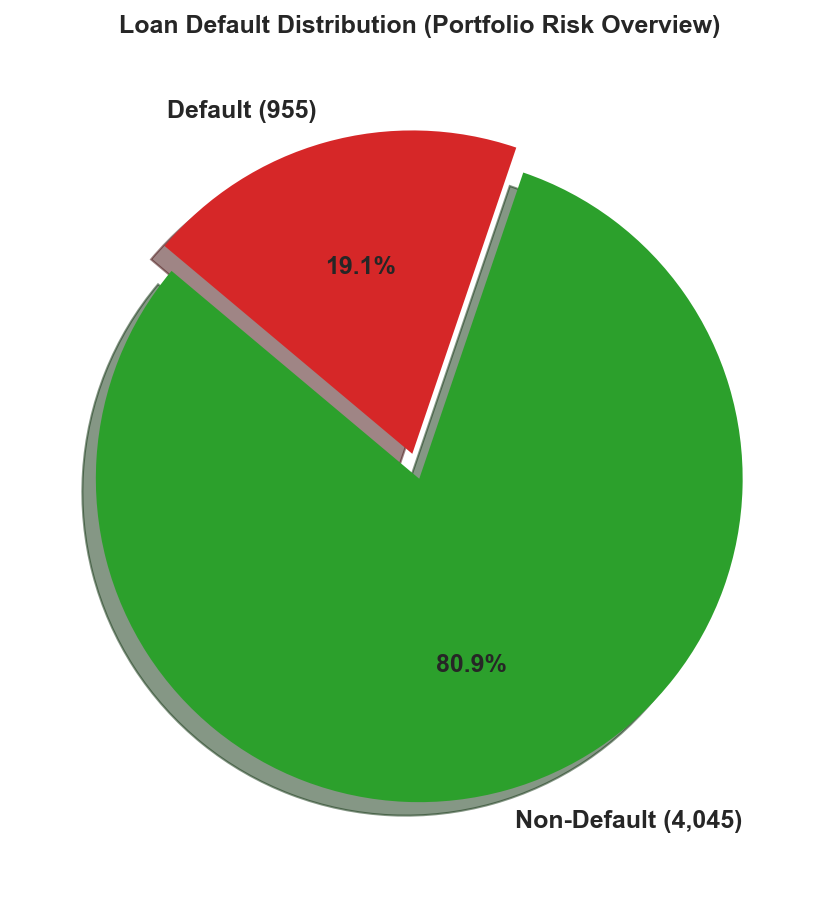

In [23]:
# 1. Loan Default Distribution — Pie Chart
plt.figure(figsize=(7, 7))
default_counts = df_cleaned['Default_Status'].value_counts()
plt.pie(default_counts, labels=[f"Non-Default ({default_counts['No']:,})", f"Default ({default_counts['Yes']:,})"],
        autopct='%1.1f%%', startangle=140, colors=['#2ca02c', '#d62728'], explode=(0, 0.08), shadow=True,
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title("Loan Default Distribution (Portfolio Risk Overview)", pad=20, weight='bold')
plt.show()


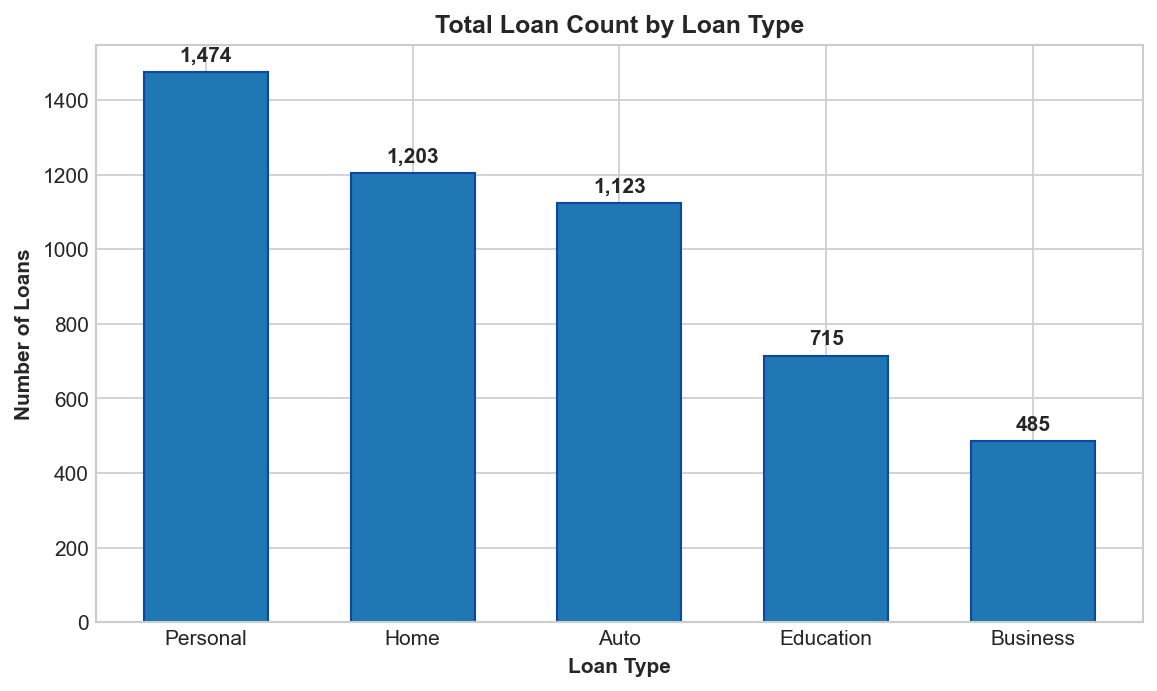

In [24]:
# 2. Loan Count by Loan Type — Bar Chart
plt.figure(figsize=(9, 5))
loan_type_counts = df_cleaned['Loan_Type'].value_counts()
bars = plt.bar(loan_type_counts.index, loan_type_counts.values, color='#1f77b4', edgecolor='#0d47a1', width=0.6)
plt.title("Total Loan Count by Loan Type", weight='bold')
plt.xlabel("Loan Type", weight='bold')
plt.ylabel("Number of Loans", weight='bold')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 20, f"{int(yval):,}", ha='center', va='bottom', fontweight='bold')
plt.show()


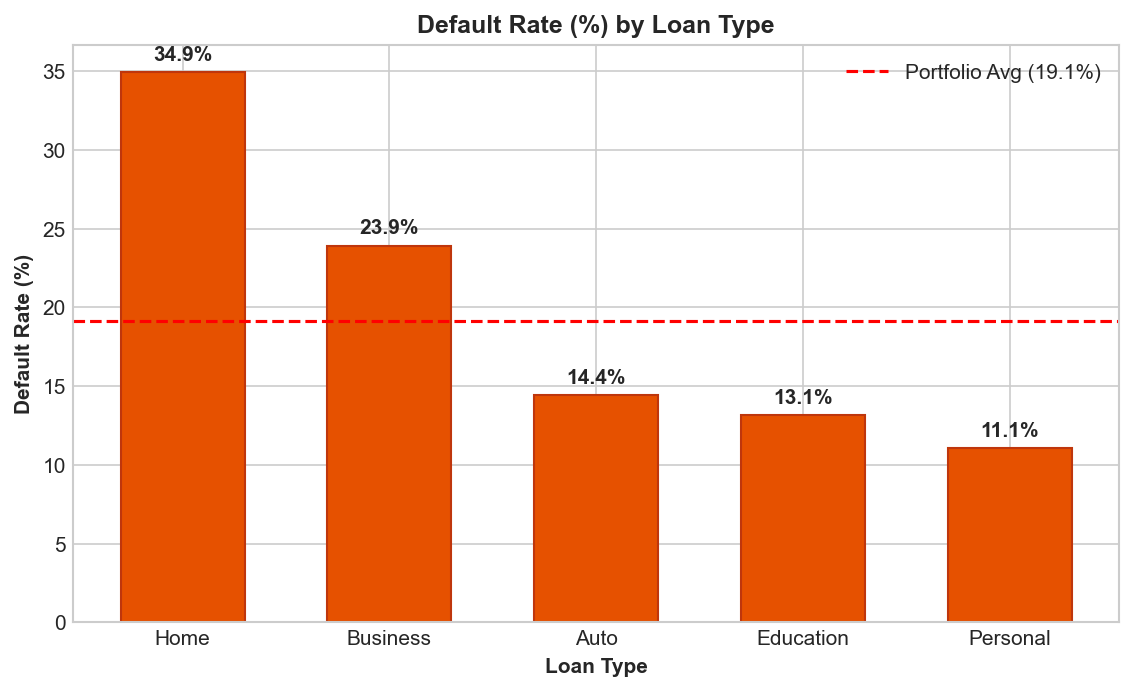

In [25]:
# 3. Default Rate by Loan Type — Bar Chart
plt.figure(figsize=(9, 5))
type_def = (df_cleaned.groupby('Loan_Type')['Default_Numeric'].mean() * 100).sort_values(ascending=False)
bars = plt.bar(type_def.index, type_def.values, color='#e65100', edgecolor='#bf360c', width=0.6)
plt.title("Default Rate (%) by Loan Type", weight='bold')
plt.xlabel("Loan Type", weight='bold')
plt.ylabel("Default Rate (%)", weight='bold')
plt.axhline(overall_default_rate, color='red', linestyle='--', label=f'Portfolio Avg ({overall_default_rate:.1f}%)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.show()


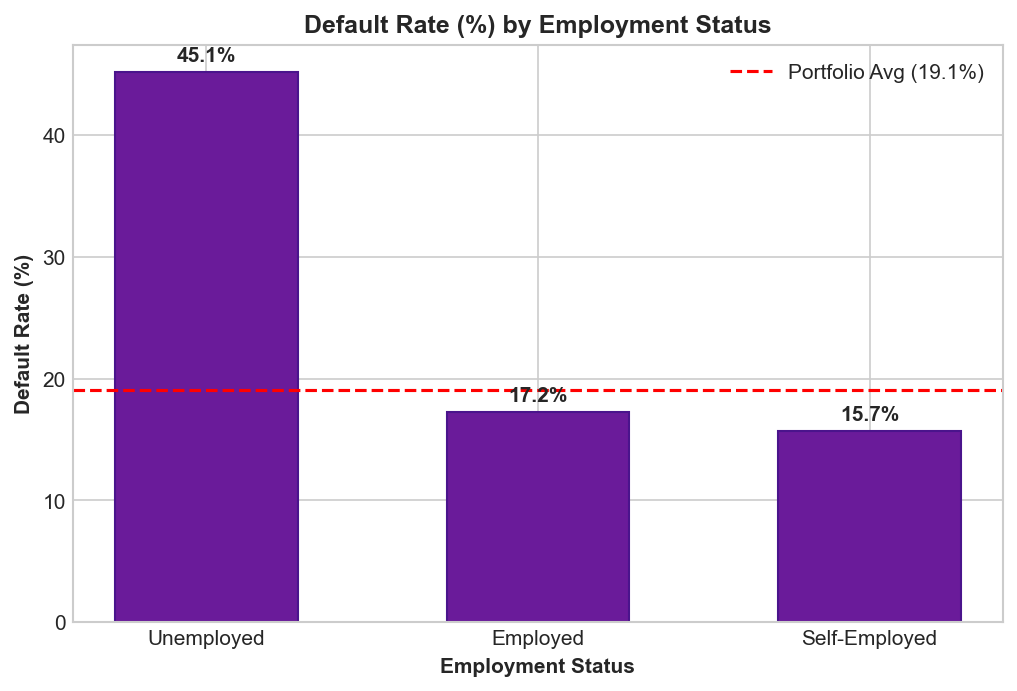

In [26]:
# 4. Default Rate by Employment Status — Bar Chart
plt.figure(figsize=(8, 5))
emp_def = (df_cleaned.groupby('Employment_Status')['Default_Numeric'].mean() * 100).sort_values(ascending=False)
bars = plt.bar(emp_def.index, emp_def.values, color='#6a1b9a', edgecolor='#4a148c', width=0.55)
plt.title("Default Rate (%) by Employment Status", weight='bold')
plt.xlabel("Employment Status", weight='bold')
plt.ylabel("Default Rate (%)", weight='bold')
plt.axhline(overall_default_rate, color='red', linestyle='--', label=f'Portfolio Avg ({overall_default_rate:.1f}%)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.6, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.show()


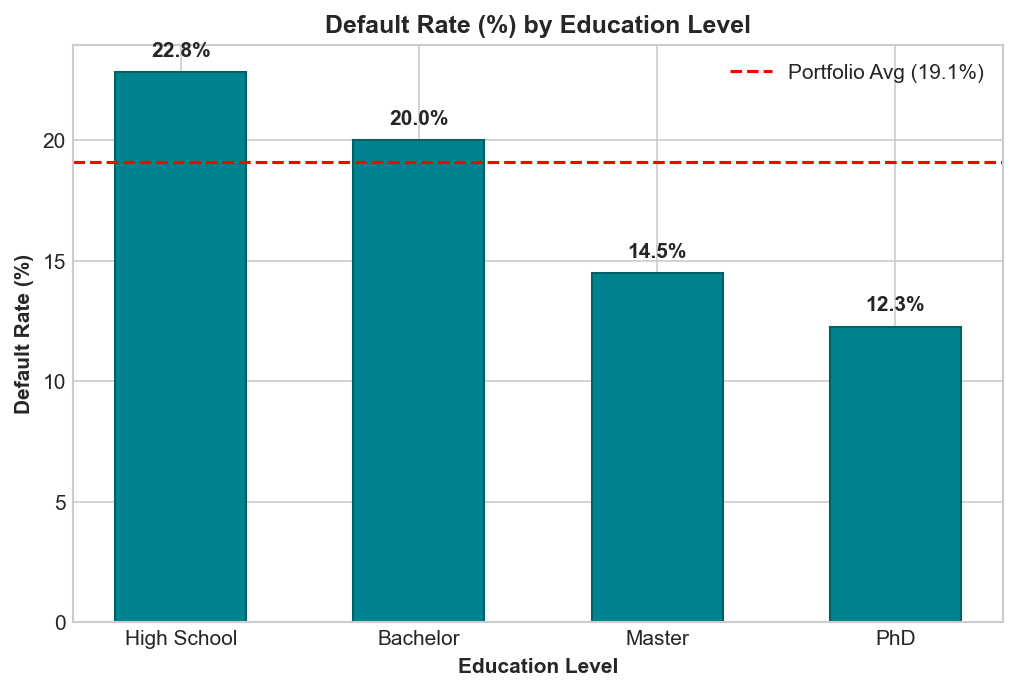

In [27]:
# 5. Default Rate by Education — Bar Chart
plt.figure(figsize=(8, 5))
edu_def = (df_cleaned.groupby('Education')['Default_Numeric'].mean() * 100).sort_values(ascending=False)
bars = plt.bar(edu_def.index, edu_def.values, color='#00838f', edgecolor='#006064', width=0.55)
plt.title("Default Rate (%) by Education Level", weight='bold')
plt.xlabel("Education Level", weight='bold')
plt.ylabel("Default Rate (%)", weight='bold')
plt.axhline(overall_default_rate, color='red', linestyle='--', label=f'Portfolio Avg ({overall_default_rate:.1f}%)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.show()


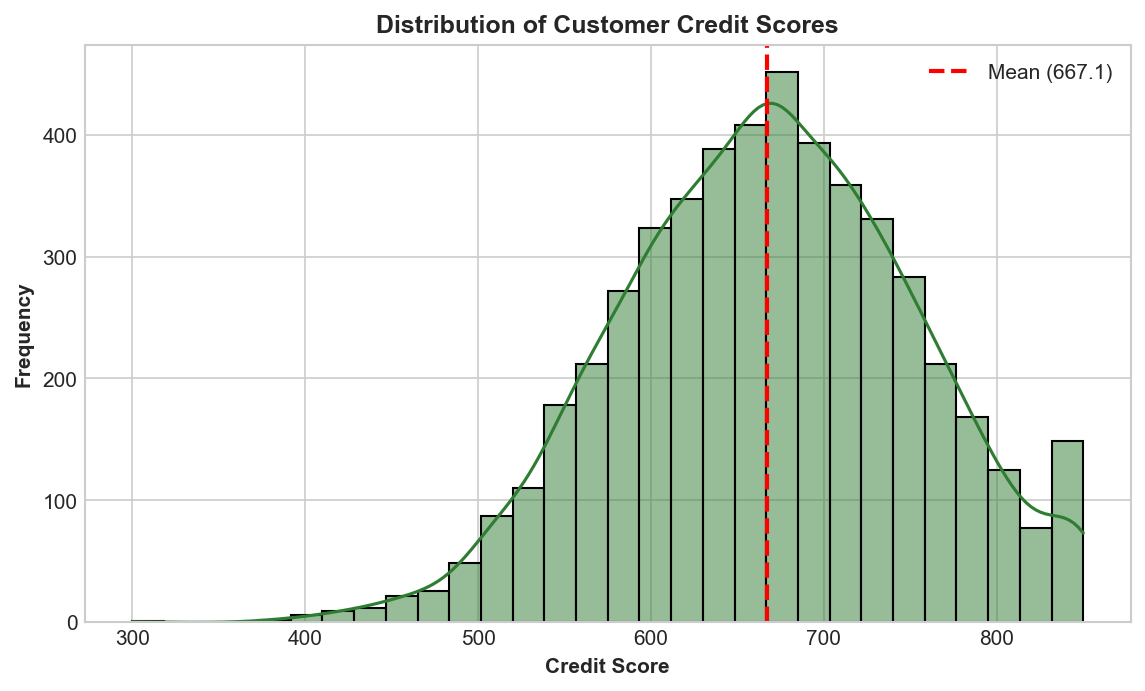

In [28]:
# 6. Credit Score Distribution — Histogram
plt.figure(figsize=(9, 5))
sns.histplot(df_cleaned['Credit_Score'], bins=30, kde=True, color='#2e7d32', edgecolor='black')
plt.axvline(avg_credit_score, color='red', linestyle='--', linewidth=2, label=f'Mean ({avg_credit_score:.1f})')
plt.title("Distribution of Customer Credit Scores", weight='bold')
plt.xlabel("Credit Score", weight='bold')
plt.ylabel("Frequency", weight='bold')
plt.legend()
plt.show()


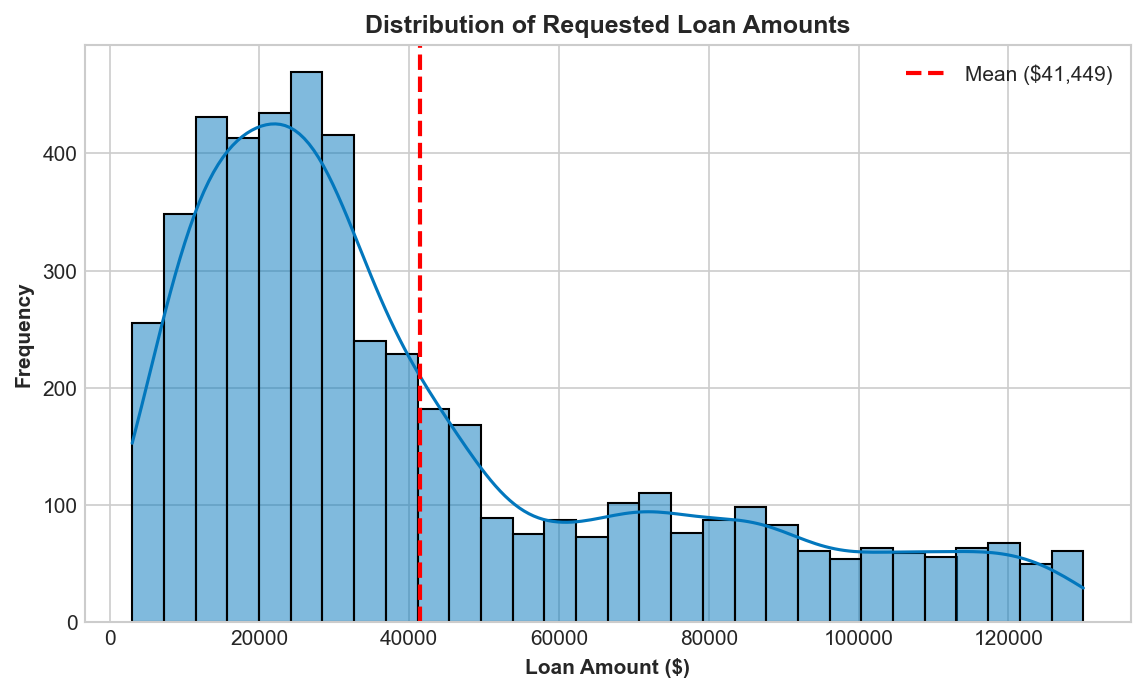

In [29]:
# 7. Loan Amount Distribution — Histogram
plt.figure(figsize=(9, 5))
sns.histplot(df_cleaned['Loan_Amount'], bins=30, kde=True, color='#0277bd', edgecolor='black')
plt.axvline(avg_loan_amount, color='red', linestyle='--', linewidth=2, label=f'Mean (${avg_loan_amount:,.0f})')
plt.title("Distribution of Requested Loan Amounts", weight='bold')
plt.xlabel("Loan Amount ($)", weight='bold')
plt.ylabel("Frequency", weight='bold')
plt.legend()
plt.show()


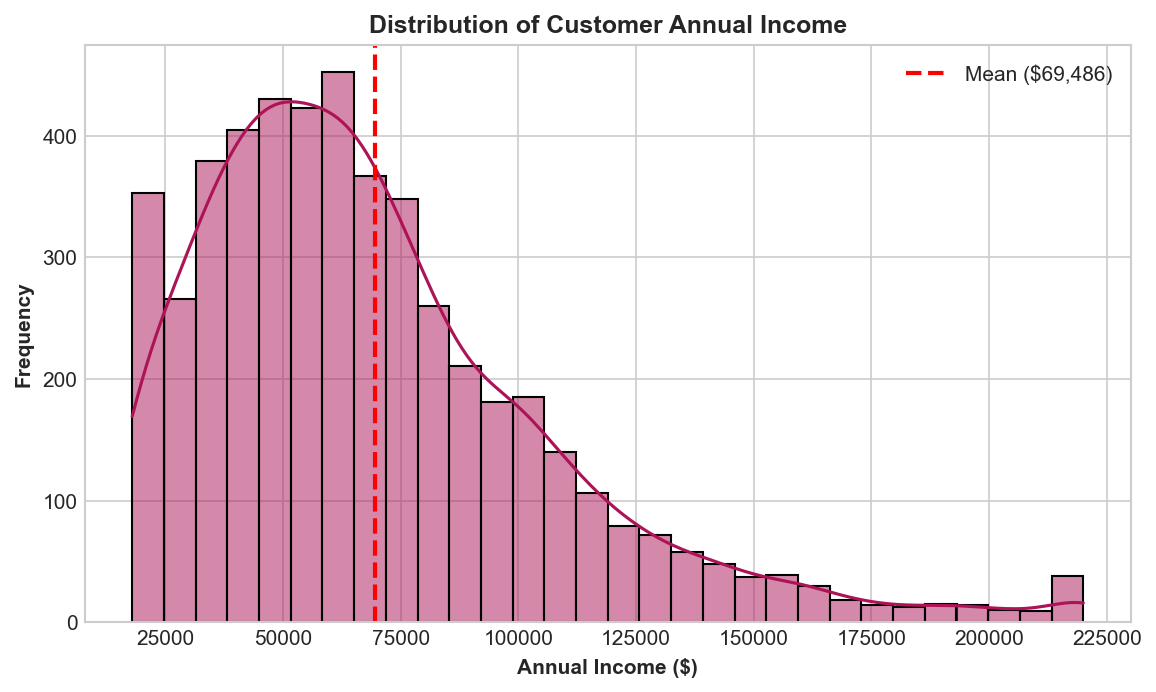

In [30]:
# 8. Annual Income Distribution — Histogram
plt.figure(figsize=(9, 5))
sns.histplot(df_cleaned['Annual_Income'], bins=30, kde=True, color='#ad1457', edgecolor='black')
plt.axvline(avg_annual_income, color='red', linestyle='--', linewidth=2, label=f'Mean (${avg_annual_income:,.0f})')
plt.title("Distribution of Customer Annual Income", weight='bold')
plt.xlabel("Annual Income ($)", weight='bold')
plt.ylabel("Frequency", weight='bold')
plt.legend()
plt.show()


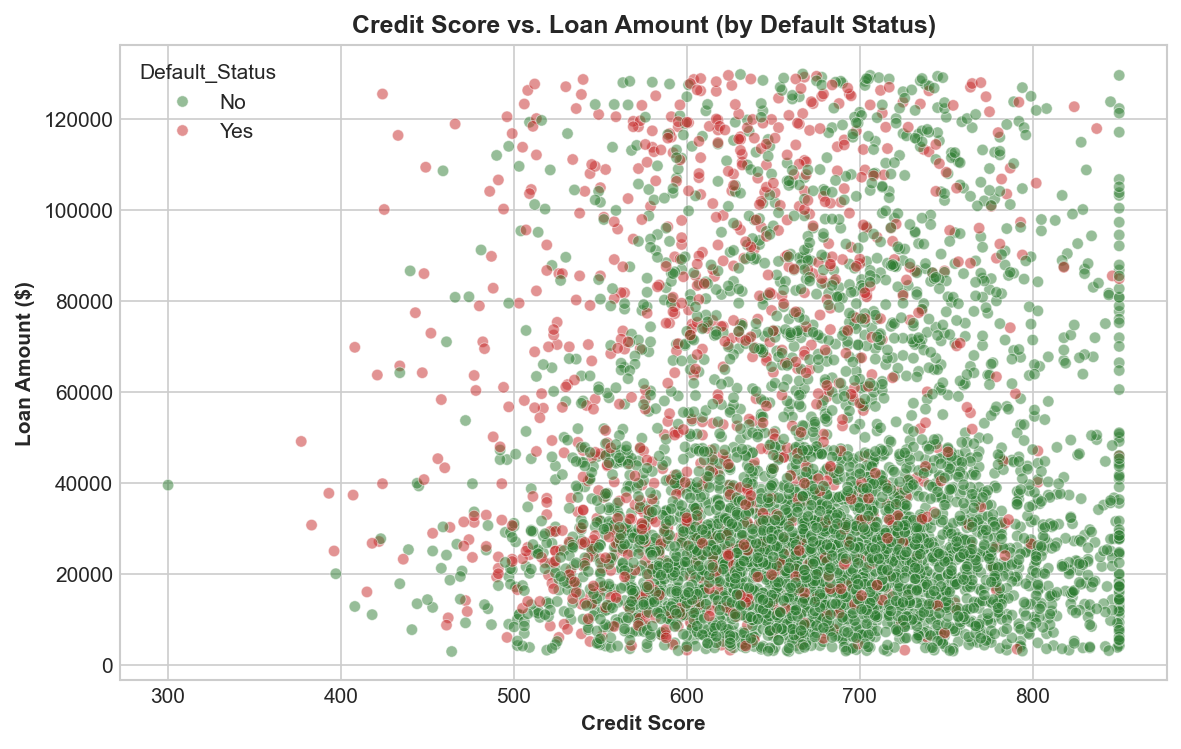

In [31]:
# 9. Credit Score vs Loan Amount — Scatter Plot
plt.figure(figsize=(9, 5.5))
sns.scatterplot(data=df_cleaned, x='Credit_Score', y='Loan_Amount', hue='Default_Status',
                palette={'No': '#2e7d32', 'Yes': '#c62828'}, alpha=0.5, s=30)
plt.title("Credit Score vs. Loan Amount (by Default Status)", weight='bold')
plt.xlabel("Credit Score", weight='bold')
plt.ylabel("Loan Amount ($)", weight='bold')
plt.show()


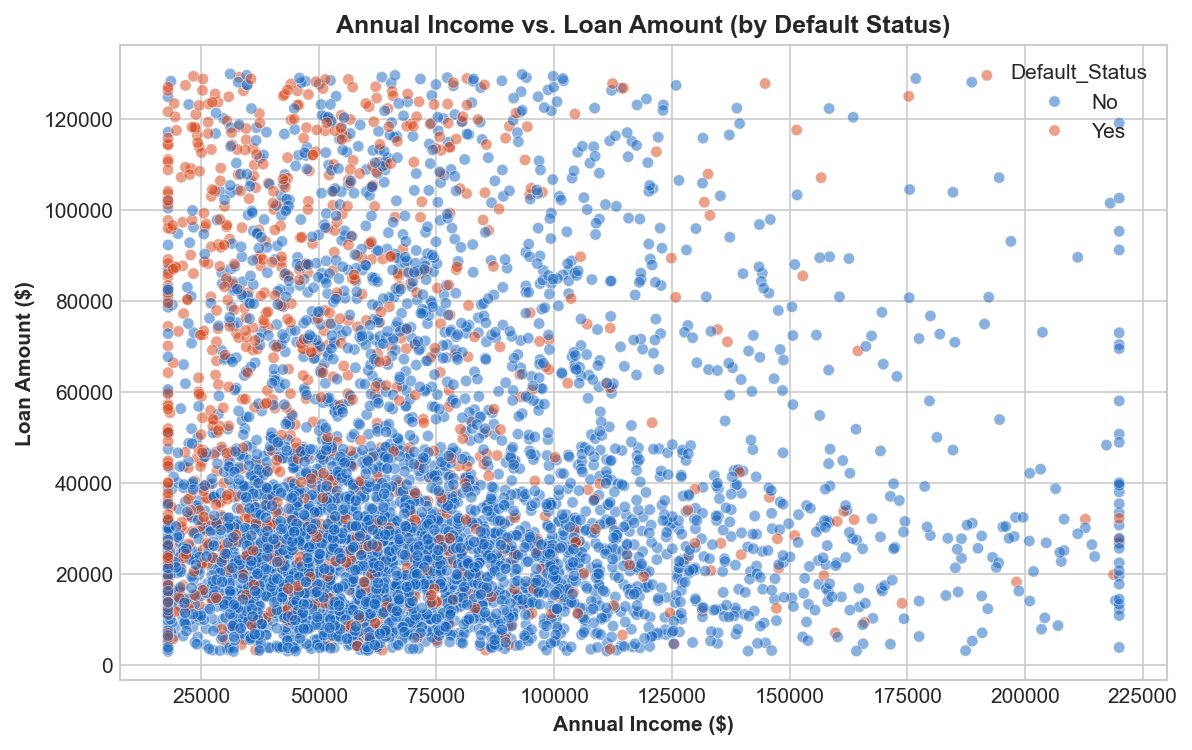

In [32]:
# 10. Income vs Loan Amount — Scatter Plot
plt.figure(figsize=(9, 5.5))
sns.scatterplot(data=df_cleaned, x='Annual_Income', y='Loan_Amount', hue='Default_Status',
                palette={'No': '#1565c0', 'Yes': '#d84315'}, alpha=0.5, s=30)
plt.title("Annual Income vs. Loan Amount (by Default Status)", weight='bold')
plt.xlabel("Annual Income ($)", weight='bold')
plt.ylabel("Loan Amount ($)", weight='bold')
plt.show()


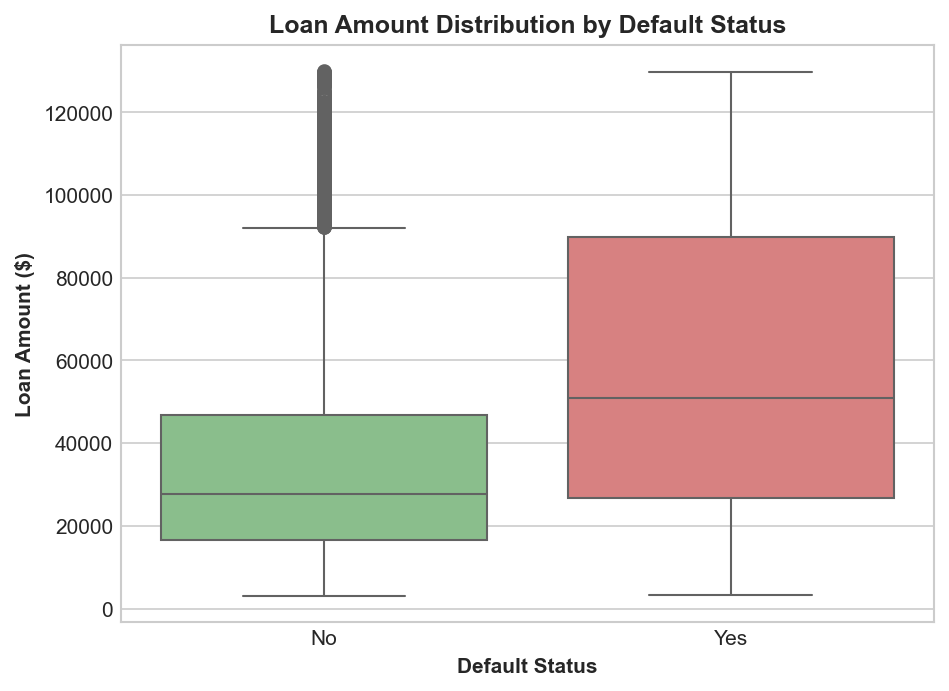

In [33]:
# 11. Loan Amount by Default Status — Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_cleaned, x='Default_Status', y='Loan_Amount', hue='Default_Status',
            palette={'No': '#81c784', 'Yes': '#e57373'}, legend=False)
plt.title("Loan Amount Distribution by Default Status", weight='bold')
plt.xlabel("Default Status", weight='bold')
plt.ylabel("Loan Amount ($)", weight='bold')
plt.show()


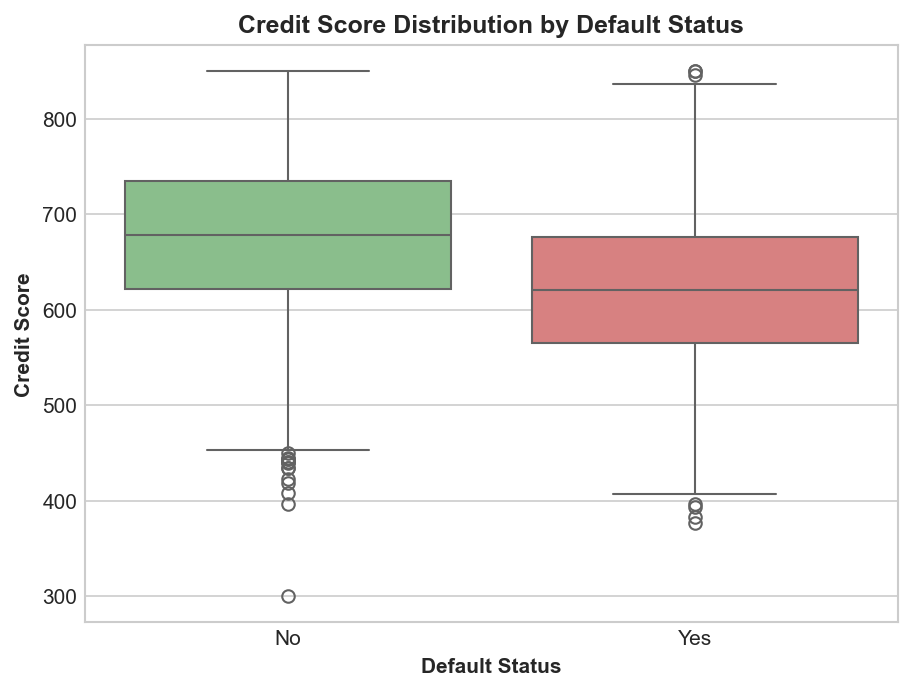

In [34]:
# 12. Credit Score by Default Status — Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_cleaned, x='Default_Status', y='Credit_Score', hue='Default_Status',
            palette={'No': '#81c784', 'Yes': '#e57373'}, legend=False)
plt.title("Credit Score Distribution by Default Status", weight='bold')
plt.xlabel("Default Status", weight='bold')
plt.ylabel("Credit Score", weight='bold')
plt.show()


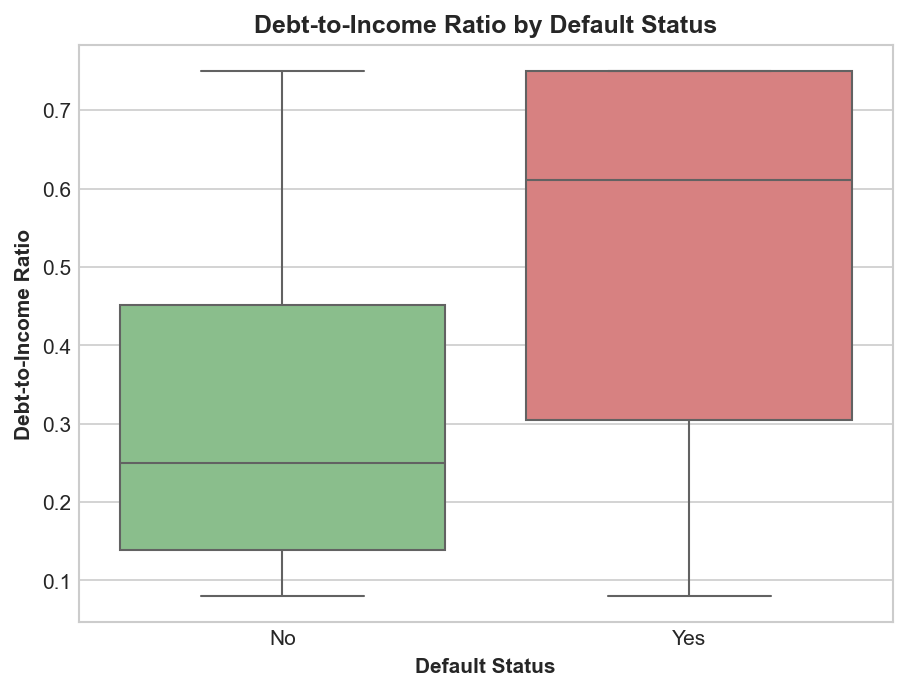

In [35]:
# 13. Debt-to-Income Ratio by Default Status — Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_cleaned, x='Default_Status', y='Debt_to_Income_Ratio', hue='Default_Status',
            palette={'No': '#81c784', 'Yes': '#e57373'}, legend=False)
plt.title("Debt-to-Income Ratio by Default Status", weight='bold')
plt.xlabel("Default Status", weight='bold')
plt.ylabel("Debt-to-Income Ratio", weight='bold')
plt.show()


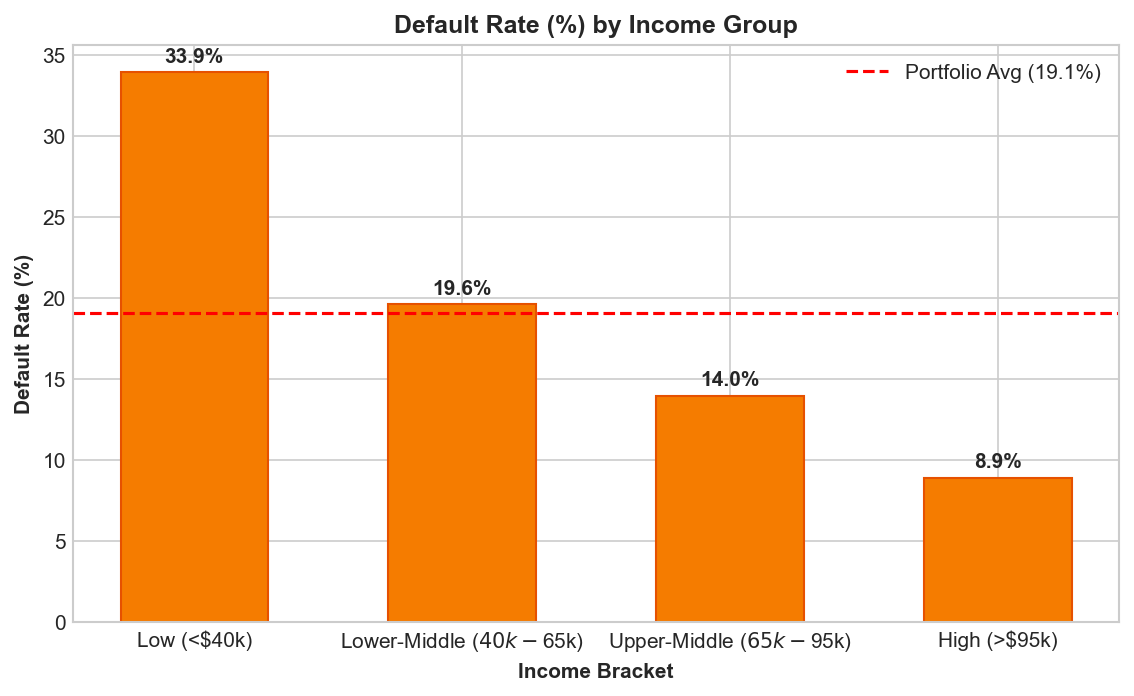

In [36]:
# 14. Default Rate by Income Group — Bar Chart
plt.figure(figsize=(9, 5))
inc_def = (df_cleaned.groupby('Income_Group', observed=False)['Default_Numeric'].mean() * 100)
bars = plt.bar(inc_def.index.astype(str), inc_def.values, color='#f57c00', edgecolor='#e65100', width=0.55)
plt.title("Default Rate (%) by Income Group", weight='bold')
plt.xlabel("Income Bracket", weight='bold')
plt.ylabel("Default Rate (%)", weight='bold')
plt.axhline(overall_default_rate, color='red', linestyle='--', label=f'Portfolio Avg ({overall_default_rate:.1f}%)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.4, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.show()


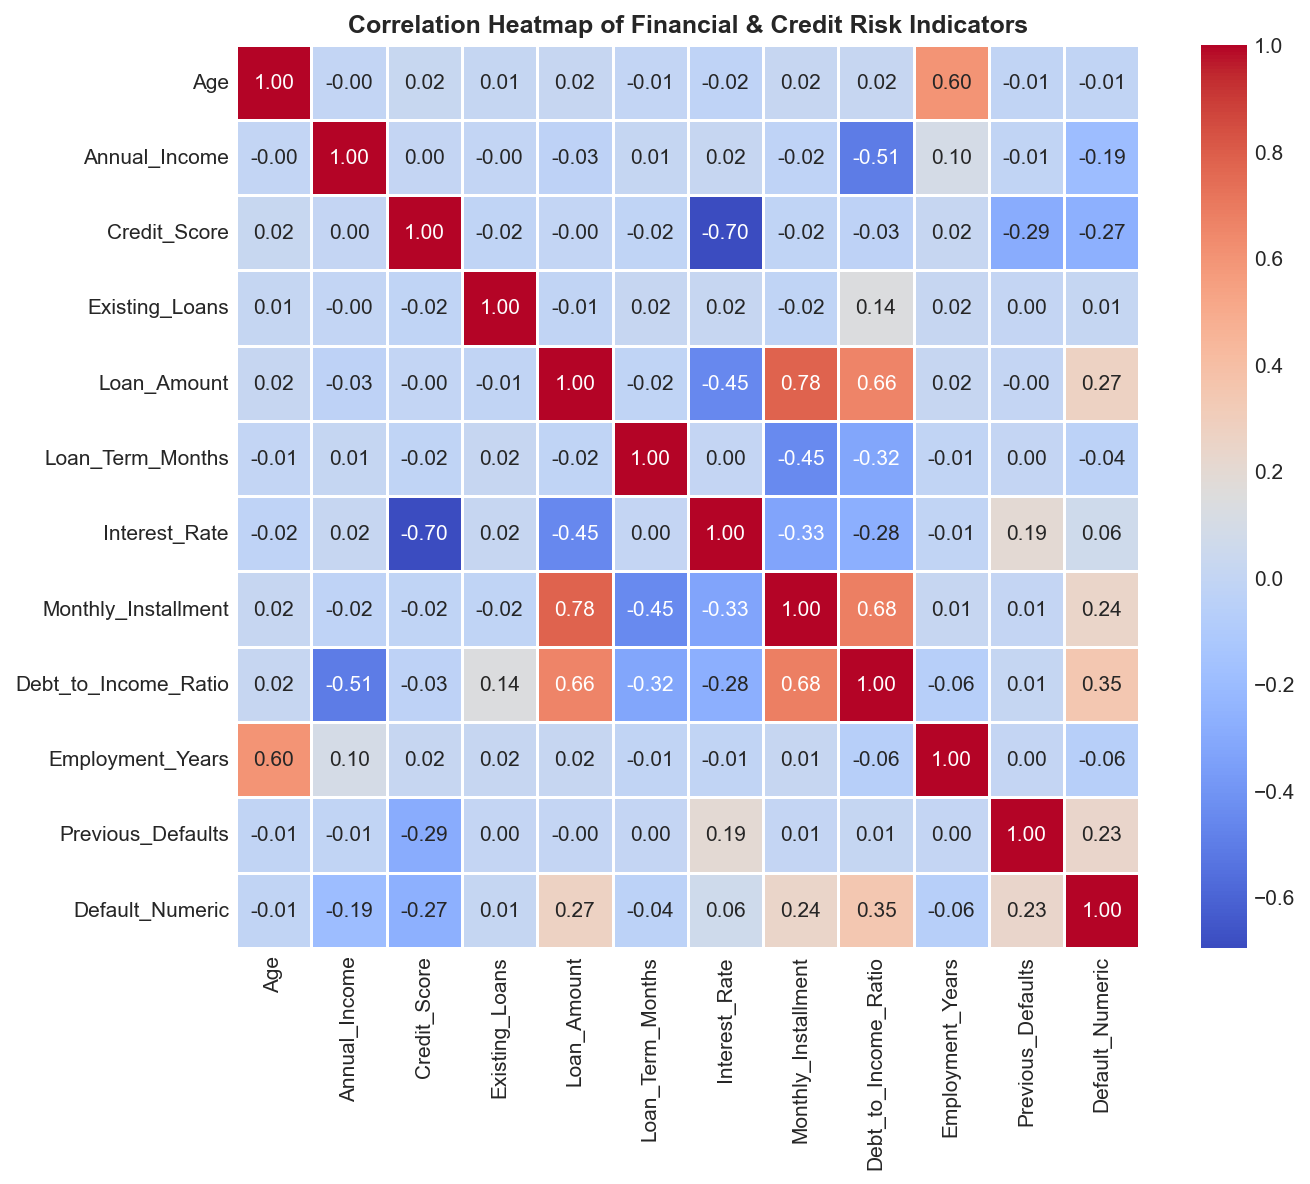

In [37]:
# 15. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['Age', 'Annual_Income', 'Credit_Score', 'Existing_Loans', 'Loan_Amount',
                'Loan_Term_Months', 'Interest_Rate', 'Monthly_Installment', 'Debt_to_Income_Ratio',
                'Employment_Years', 'Previous_Defaults', 'Default_Numeric']
corr_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Financial & Credit Risk Indicators", weight='bold')
plt.tight_layout()
plt.show()
